In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

data_path = "/home/hpc/b292dc/b292dc16/vesuvius_project/data/patches.npy"

patches = np.load(data_path)

print("Full dataset:", patches.shape)

# Use only 2000 patches for lightweight experiments
patches = patches[:2000]

patches = patches.astype("float32") 
patches = np.expand_dims(patches, -1)

print("Experiment dataset:", patches.shape)

Full dataset: (163072, 128, 128)
Experiment dataset: (2000, 128, 128, 1)


In [3]:
from sklearn.model_selection import train_test_split

train_p, test_p = train_test_split(patches, test_size=0.2, random_state=42)
train_p, val_p = train_test_split(train_p, test_size=0.2, random_state=42)

print("Train:", train_p.shape)
print("Validation:", val_p.shape)
print("Test:", test_p.shape)

Train: (1280, 128, 128, 1)
Validation: (320, 128, 128, 1)
Test: (400, 128, 128, 1)


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

model = Sequential([
    Conv2D(8, 3, activation="relu", padding="same", input_shape=(128,128,1)),
    MaxPooling2D(2, padding="same"),

    Conv2D(16, 3, activation="relu", padding="same"),
    MaxPooling2D(2, padding="same"),

    Conv2D(16, 3, activation="relu", padding="same"),
    UpSampling2D(2),

    Conv2D(8, 3, activation="relu", padding="same"),
    UpSampling2D(2),

    Conv2D(1, 3, activation="sigmoid", padding="same")
])

model.compile(optimizer="adam", loss="mse")

model.summary()

I0000 00:00:1773406976.935065 2793260 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773406978.841125 2793260 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773406999.560386 2793260 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/hpc/b292dc/b292dc16/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773407007.389387 2793260 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_p,
    train_p,
    validation_data=(val_p, val_p),
    epochs=3,
    batch_size=8
)

Epoch 1/3
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0106 - val_loss: 0.0074
Epoch 2/3
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0068 - val_loss: 0.0064
Epoch 3/3
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0062 - val_loss: 0.0059


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


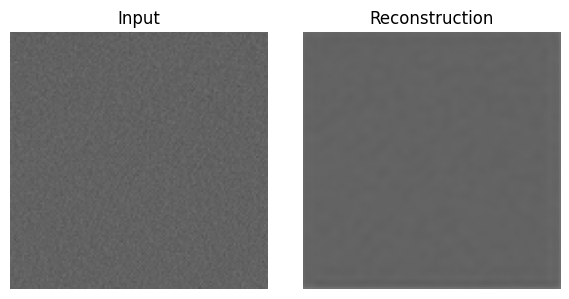

Saved: /home/hpc/b292dc/b292dc16/vesuvius_project/figures/reconstruction_0.png


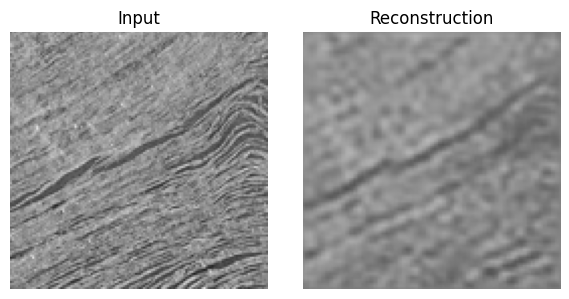

Saved: /home/hpc/b292dc/b292dc16/vesuvius_project/figures/reconstruction_1.png


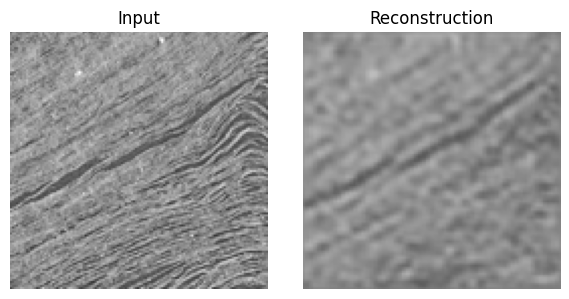

Saved: /home/hpc/b292dc/b292dc16/vesuvius_project/figures/reconstruction_2.png


In [6]:
import os
import matplotlib.pyplot as plt

figures_path = "/home/hpc/b292dc/b292dc16/vesuvius_project/figures"
os.makedirs(figures_path, exist_ok=True)

samples = test_p[:3]
preds = model.predict(samples)

for i in range(len(samples)):

    fig, ax = plt.subplots(1,2, figsize=(6,3))

    ax[0].imshow(samples[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax[0].set_title("Input")
    ax[0].axis("off")

    ax[1].imshow(preds[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title("Reconstruction")
    ax[1].axis("off")

    plt.tight_layout()

    path = os.path.join(figures_path, f"reconstruction_{i}.png")
    plt.savefig(path)

    plt.show()

    print("Saved:", path)

In [7]:
preds = model.predict(test_p)

mse = np.mean((test_p - preds) ** 2)

print("Test Reconstruction MSE:", mse)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Test Reconstruction MSE: 0.005823836


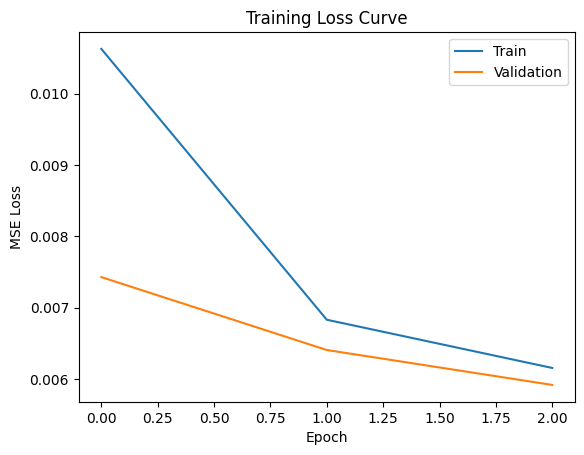

In [8]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train","Validation"])

plt.savefig(figures_path + "/training_curve.png")